In [28]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
# 1. Pull the maximum available data
ticker = "BTC-USD"
df = yf.download(ticker, period="max")

# 2. Engineer Features (RSI)
window = 14
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -1 * delta.clip(upper=0)
ema_up = up.ewm(com=window-1, adjust=False).mean()
ema_down = down.ewm(com=window-1, adjust=False).mean()
rs = ema_up / ema_down
df['RSI'] = 100 - (100 / (1 + rs))

# 3. Engineer Features (Bollinger Bands)
df['MA20'] = df['Close'].rolling(window=20).mean()
df['STD20'] = df['Close'].rolling(window=20).std()
df['Upper_Band'] = df['MA20'] + (df['STD20'] * 2)
df['Lower_Band'] = df['MA20'] - (df['STD20'] * 2)

# 4. Data Scientist "Target" Column (Did price go up the next day?)
# Useful for training your Pattern Recognition Model
df['Target_Next_Day_Up'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# 5. Save to CSV
df.to_csv('bitcoin_pattern_recognition_data.csv')

[*********************100%***********************]  1 of 1 completed


In [30]:
df.head(30)

Price,Close,High,Low,Open,Volume,RSI,MA20,STD20,Upper_Band,Lower_Band,Target_Next_Day_Up
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,,,,
Date,,,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,NaN,NaN,NaN,NaN,NaN,0
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,0.000000,NaN,NaN,NaN,NaN,0
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,0.000000,NaN,NaN,NaN,NaN,1
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,3.215775,NaN,NaN,NaN,NaN,0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,3.138104,NaN,NaN,NaN,NaN,1
2014-09-22,402.152008,406.915985,397.130005,399.100006,24127600,3.963347,NaN,NaN,NaN,NaN,1
2014-09-23,435.790985,441.557007,396.196991,402.092010,45099500,12.107304,NaN,NaN,NaN,NaN,0
2014-09-24,423.204987,436.112000,421.131989,435.751007,30627700,11.707282,NaN,NaN,NaN,NaN,0


In [31]:
df.isnull().sum()

Price               Ticker 
Close               BTC-USD     0
High                BTC-USD     0
Low                 BTC-USD     0
Open                BTC-USD     0
Volume              BTC-USD     0
RSI                             1
MA20                           19
STD20                          19
Upper_Band                     19
Lower_Band                     19
Target_Next_Day_Up              0
dtype: int64

In [32]:
df.columns = df.columns.set_levels(
    [level.str.lower() for level in df.columns.levels]
)

In [33]:
df.columns

MultiIndex([(             'close', 'btc-usd'),
            (              'high', 'btc-usd'),
            (               'low', 'btc-usd'),
            (              'open', 'btc-usd'),
            (            'volume', 'btc-usd'),
            (               'rsi',        ''),
            (              'ma20',        ''),
            (             'std20',        ''),
            (        'upper_band',        ''),
            (        'lower_band',        ''),
            ('target_next_day_up',        '')],
           names=['Price', 'Ticker'])

In [34]:
df.head()

Price,close,high,low,open,volume,rsi,ma20,std20,upper_band,lower_band,target_next_day_up
Ticker,btc-usd,btc-usd,btc-usd,btc-usd,btc-usd,,,,,,
Date,,,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,NaN,NaN,NaN,NaN,NaN,0
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,0.000000,NaN,NaN,NaN,NaN,0
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,0.000000,NaN,NaN,NaN,NaN,1
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,3.215775,NaN,NaN,NaN,NaN,0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,3.138104,NaN,NaN,NaN,NaN,1


In [35]:
df.columns = df.columns.droplevel(1)

In [36]:
df.head()

Price,close,high,low,open,volume,rsi,ma20,std20,upper_band,lower_band,target_next_day_up
Date,,,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,NaN,NaN,NaN,NaN,NaN,0
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,0.000000,NaN,NaN,NaN,NaN,0
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,0.000000,NaN,NaN,NaN,NaN,1
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,3.215775,NaN,NaN,NaN,NaN,0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,3.138104,NaN,NaN,NaN,NaN,1


In [37]:
df = df.rename(columns={
    'close': 'close_price',
    'high': 'high_price',
    'low': 'low_price',
    'open': 'open_price'
})

In [38]:
df

Price,close_price,high_price,low_price,open_price,volume,rsi,ma20,std20,upper_band,lower_band,target_next_day_up
Date,,,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,NaN,NaN,NaN,NaN,NaN,0
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,0.000000,NaN,NaN,NaN,NaN,0
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,0.000000,NaN,NaN,NaN,NaN,1
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,3.215775,NaN,NaN,NaN,NaN,0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,3.138104,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
2026-04-20,75872.523438,76575.359375,73775.570312,73854.250000,39674447916,60.415794,71992.725391,3245.605583,78483.936556,65501.514225,1
2026-04-21,76352.773438,76881.476562,74852.671875,75872.828125,36453522626,61.483573,72406.436328,3247.762860,78901.962047,65910.910609,1
2026-04-22,78203.101562,79468.000000,76159.578125,76354.218750,48336654537,65.360578,72972.162891,3221.350321,79414.863532,66529.462250,1


In [39]:
df.close_price.describe()

count      4238.000000
mean      28163.769430
std       32248.205548
min         178.102997
25%        3320.875427
50%       11383.398926
75%       44542.057617
max      124752.531250
Name: close_price, dtype: float64

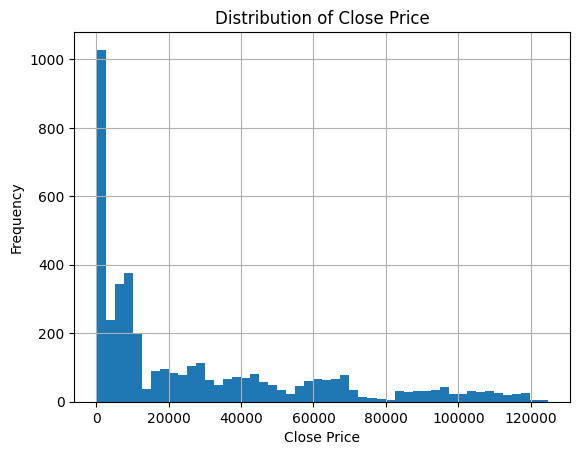

In [40]:
df['close_price'].hist(bins=50)
plt.title('Distribution of Close Price')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='Date'>

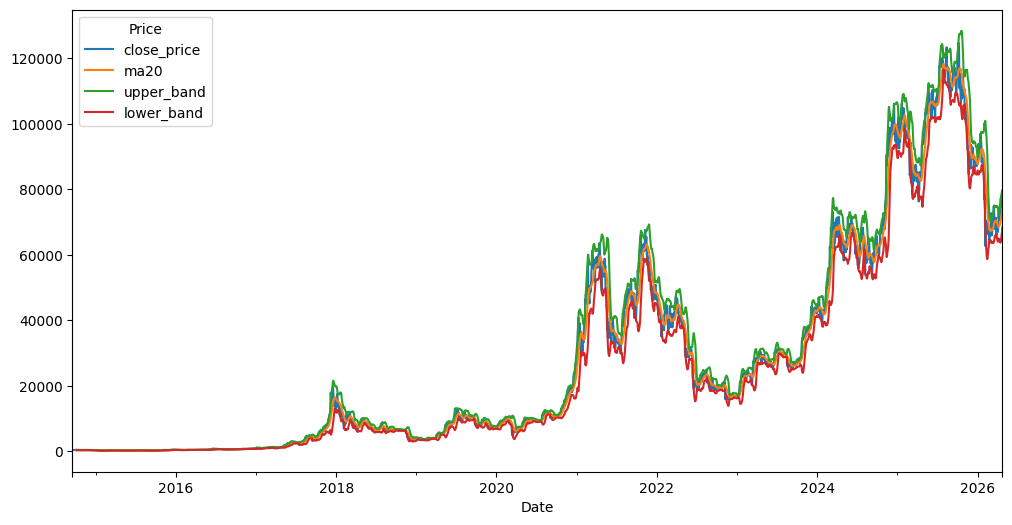

In [41]:
df[['close_price', 'ma20', 'upper_band', 'lower_band']].plot(figsize=(12,6))

<Axes: >

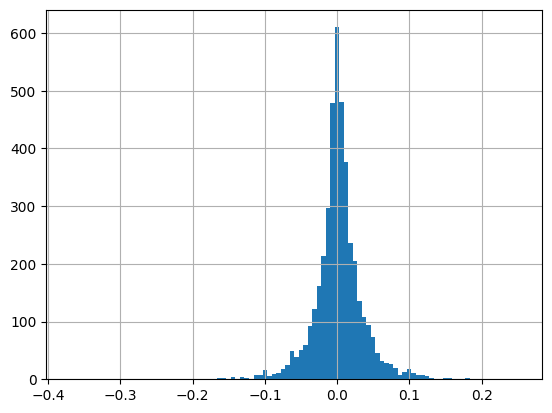

In [42]:
df['close_price'].pct_change().hist(bins=100)

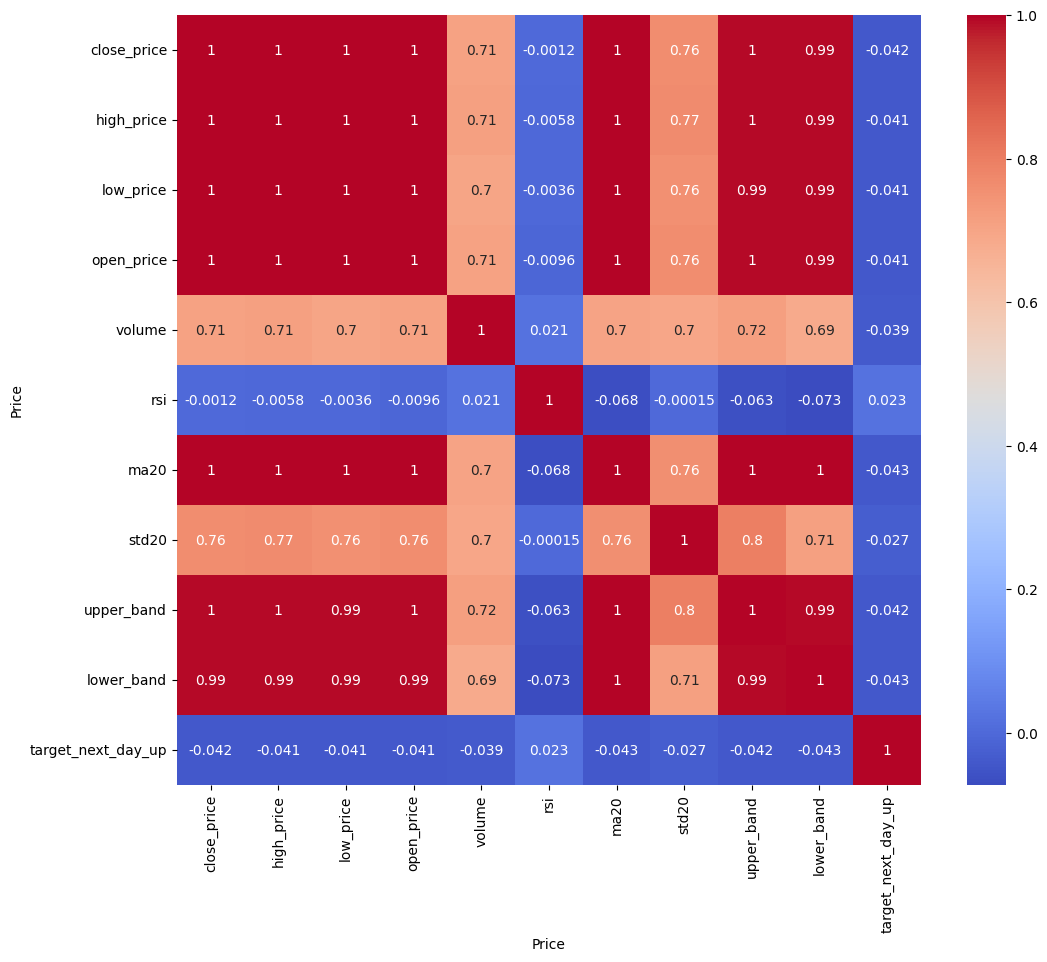

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.show()

In [50]:
df.groupby('target_next_day_up')['rsi'].mean()

target_next_day_up
0    52.477470
1    53.127482
Name: rsi, dtype: float64

In [48]:
df.target_next_day_up.value_counts()

target_next_day_up
1    2224
0    2014
Name: count, dtype: int64

In [52]:
(df[(df['rsi'] < 30)]['target_next_day_up'].mean())

np.float64(0.5953757225433526)

In [55]:
from sklearn.ensemble import RandomForestClassifier

features = df[['rsi', 'ma20', 'std20', 'volume']]
target = df['target_next_day_up']

model = RandomForestClassifier()
model.fit(features, target)

print(model.feature_importances_)

[0.2622393  0.24498066 0.24081167 0.25196837]


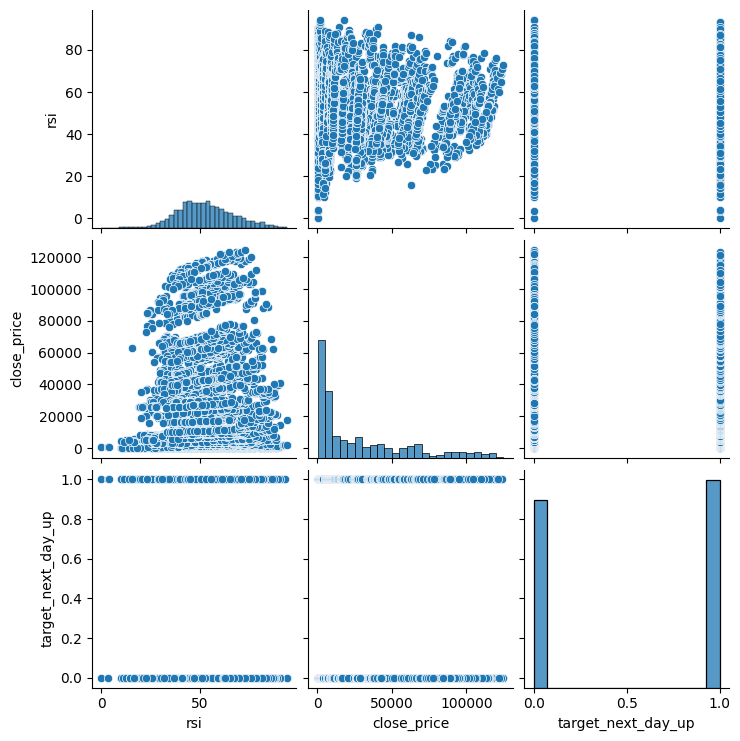

In [56]:
sns.pairplot(df[['rsi', 'close_price', 'target_next_day_up']])